## Data Cleaning & Pre-Processing 

In [57]:
import pandas as pd 
import numpy as np 

from pathlib import Path
import os

# Set Pandas display options to show all rows and columns
pd.set_option('display.max_rows', None)     # Show all rows
pd.set_option('display.max_columns', None) # Show all columns

# Optional: Adjust column width for better readability
pd.set_option('display.max_colwidth', None)


In [58]:

raw_dir = Path.cwd().parent / "data" / "raw"

credits_dir = raw_dir / "credits.csv"
keywords_dir = raw_dir / "keywords.csv"
links_small_dir = raw_dir / "links_small.csv"
links_dir = raw_dir / "links.csv"
movie_metadata_dir = raw_dir / "movies_metadata.csv"
ratings_small_dir = raw_dir / "ratings_small.csv"
rating_dir = raw_dir / "ratings.csv"


In [59]:
movies = pd.read_csv(movie_metadata_dir)
movies.sample(1)


C:\Users\Crashlar\AppData\Local\Temp\ipykernel_31912\2396986331.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies = pd.read_csv(movie_metadata_dir)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
14137,FALSE,NaN,0,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, 'name': 'Drama'}]",NaN,57412,tt0026866,en,Peter Ibbetson,"Architect Peter Ibbetson is hired by the Duke of Towers to design a building for him. Ibbetson discovers that the Duchess of Towers, Mary, is his now-grown childhood sweetheart. Their love revives, but Peter is sentenced to life in prison for an accidental killing. Mary comes to him in dreams and they are able to live out their romance in a dream world.",0.484253,/xHbpHk7xvWUn9RG5UC9GcDdgzby.jpg,"[{'name': 'Paramount Pictures', 'id': 4}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",07-11-1935,0.0,88.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Franï¿½ï¿½ai",Released,NaN,Peter Ibbetson,False,5.6,5.0


In [60]:
movies.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [61]:
list_of_remove_colm = ['belongs_to_collection' , "budget" , "homepage" , "original_language" , "original_title" , "poster_path" , "revenue" , "status" , "tagline" , "video" , "popularity" , "imdb_id"]

movies.drop(columns = list_of_remove_colm , inplace = True)


In [62]:
movies.sample()


,adult,genres,id,overview,production_companies,production_countries,release_date,runtime,spoken_languages,title,vote_average,vote_count
11158,FALSE,"[{'id': 53, 'name': 'Thriller'}, {'id': 80, 'name': 'Crime'}, {'id': 10769, 'name': 'Foreign'}]",31979,An examination of the malevolent London underworld with it's despicable criminal underground. Ray (Mick Rossi) just finished an eight year prison sentence after getting set up. Now he is back on the streets to settle the score.,[],"[{'iso_3166_1': 'GB', 'name': 'United Kingdom'}]",01-01-2006,87.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Played,2.4,6.0


In [63]:
md = movies.copy()
md.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   adult                 45466 non-null  object 
 1   genres                45466 non-null  object 
 2   id                    45466 non-null  object 
 3   overview              44512 non-null  object 
 4   production_companies  45463 non-null  object 
 5   production_countries  45463 non-null  object 
 6   release_date          45379 non-null  object 
 7   runtime               45203 non-null  float64
 8   spoken_languages      45460 non-null  object 
 9   title                 45460 non-null  object 
 10  vote_average          45460 non-null  float64
 11  vote_count            45460 non-null  float64
dtypes: float64(3), object(9)
memory usage: 4.2+ MB


In [64]:
md.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   adult                 45466 non-null  object 
 1   genres                45466 non-null  object 
 2   id                    45466 non-null  object 
 3   overview              44512 non-null  object 
 4   production_companies  45463 non-null  object 
 5   production_countries  45463 non-null  object 
 6   release_date          45379 non-null  object 
 7   runtime               45203 non-null  float64
 8   spoken_languages      45460 non-null  object 
 9   title                 45460 non-null  object 
 10  vote_average          45460 non-null  float64
 11  vote_count            45460 non-null  float64
dtypes: float64(3), object(9)
memory usage: 4.2+ MB


In [65]:
md.fillna({
    'overview': "Na",
    'production_companies': "Na",
    'production_countries': "Na",
    'release_date': "Na",
    'runtime': "0",
    'spoken_languages': "eng"
}, inplace=True)


In [66]:
md.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   adult                 45466 non-null  object 
 1   genres                45466 non-null  object 
 2   id                    45466 non-null  object 
 3   overview              45466 non-null  object 
 4   production_companies  45466 non-null  object 
 5   production_countries  45466 non-null  object 
 6   release_date          45466 non-null  object 
 7   runtime               45466 non-null  object 
 8   spoken_languages      45466 non-null  object 
 9   title                 45460 non-null  object 
 10  vote_average          45460 non-null  float64
 11  vote_count            45460 non-null  float64
dtypes: float64(2), object(10)
memory usage: 4.2+ MB


In [67]:
md.head(2)


,adult,genres,id,overview,production_companies,production_countries,release_date,runtime,spoken_languages,title,vote_average,vote_count
0,FALSE,"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]",862,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.","[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",30-10-1995,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Toy Story,7.7,5415.0
1,FALSE,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 10751, 'name': 'Family'}]",8844,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures.","[{'name': 'TriStar Pictures', 'id': 559}, {'name': 'Teitler Film', 'id': 2550}, {'name': 'Interscope Communications', 'id': 10201}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",15-12-1995,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Franï¿½ï¿½ai",Jumanji,6.9,2413.0


In [68]:
import ast
def convert(text):
    L = []
    for i in ast.literal_eval(text):
        L.append(i['name']) 
    return L 


In [69]:
md['genres'] = md['genres'].apply(convert)
md.head()


,adult,genres,id,overview,production_companies,production_countries,release_date,runtime,spoken_languages,title,vote_average,vote_count
0,FALSE,"[Animation, Comedy, Family]",862,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.","[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",30-10-1995,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Toy Story,7.7,5415.0
1,FALSE,"[Adventure, Fantasy, Family]",8844,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures.","[{'name': 'TriStar Pictures', 'id': 559}, {'name': 'Teitler Film', 'id': 2550}, {'name': 'Interscope Communications', 'id': 10201}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",15-12-1995,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Franï¿½ï¿½ai",Jumanji,6.9,2413.0
2,FALSE,"[Romance, Comedy]",15602,"A family wedding reignites the ancient feud between next-door neighbors and fishing buddies John and Max. Meanwhile, a sultry Italian divorcï¿½ï¿½e opens a restaurant at the local bait shop, alarming the locals who worry she'll scare the fish away. But she's less interested in seafood than she is in cooking up a hot time with","[{'name': 'Warner Bros.', 'id': 6194}, {'name': 'Lancaster Gate', 'id': 19464}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",22-12-1995,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Grumpier Old Men,6.5,92.0
3,FALSE,"[Comedy, Drama, Romance]",31357,"Cheated on, mistreated and stepped on, the women are holding their breath, waiting for the elusive ""good man"" to break a string of less-than-stellar lovers. Friends and confidants Vannah, Bernie, Glo and Robin talk it all out, determined to find a better way to breathe.","[{'name': 'Twentieth Century Fox Film Corporation', 'id': 306}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",22-12-1995,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Waiting to Exhale,6.1,34.0
4,FALSE,[Comedy],11862,"Just when George Banks has recovered from his daughter's wedding, he receives the news that she's pregnant ... and that George's wife, Nina, is expecting too. He was planning on selling their home, but that's a plan that -- like George -- will have to change with the arrival of both a grandchild and a kid of his own.","[{'name': 'Sandollar Productions', 'id': 5842}, {'name': 'Touchstone Pictures', 'id': 9195}]","[{'iso_3166_1': 'US', 'name': 'United States of America'}]",10-02-1995,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Father of the Bride Part II,5.7,173.0


In [70]:
def convert1(text):
    if isinstance(text, list):  # already parsed
        return [d['name'] for d in text]
    try:
        data = ast.literal_eval(text)
        return [d['name'] for d in data]
    except Exception:
        return []


In [71]:
md['production_companies'] = md.production_companies.apply(convert1)


In [72]:
md.sample(2)


,adult,genres,id,overview,production_companies,production_countries,release_date,runtime,spoken_languages,title,vote_average,vote_count
3127,FALSE,[Drama],32015,"An unabashed exercise in cinema stylistics, I Am Cuba is pro-Castro/anti-Batista rhetoric dressed up in the finest clothes. The film's four dramatic stories take place in the final days of the Batista regime; the first two illustrate the ills that led to the revolution, the third and fourth the call to arms which cut across social and economic lines.",[],"[{'iso_3166_1': 'RU', 'name': 'Russia'}, {'iso_3166_1': 'CU', 'name': 'Cuba'}]",06-09-1964,141.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'es', 'name': 'Espaï¿½ï¿½o",I Am Cuba,8.0,33.0
40982,FALSE,[Documentary],333099,"In 2005, 20-year-old Ryan Ferguson was convicted and sentenced to 40 years in prison for a crime he did not commit. dream/killer is the story of how his father Bill embarked on 10-year campaign to prove Ryanï¿½ï¿½ï¿½s innocence. The film is chock-full of incredible characters. From the questionable District Attorney Kevin Crane, and the highly-confused witness Chuck Erickson, to the high-powered Chicago attorney Kathleen Zellner, the doc depicts both a highly flawed justice system, as well as one that can work brilli",[],[],19-04-2015,107.0,[],Dream/Killer,7.3,3.0


In [73]:
import ast

# dictionary mapping full names to short codes
country_map = {
    "Afghanistan": "AF", "Albania": "AL", "Algeria": "DZ", "Andorra": "AD", "Angola": "AO",
    "Argentina": "AR", "Armenia": "AM", "Australia": "AU", "Austria": "AT", "Azerbaijan": "AZ",
    "Bahamas": "BS", "Bahrain": "BH", "Bangladesh": "BD", "Belgium": "BE", "Belize": "BZ",
    "Benin": "BJ", "Bhutan": "BT", "Bolivia": "BO", "Bosnia and Herzegovina": "BA", "Botswana": "BW",
    "Brazil": "BR", "Brunei Darussalam": "BN", "Bulgaria": "BG", "Burkina Faso": "BF", "Burundi": "BI",
    "Cambodia": "KH", "Cameroon": "CM", "Canada": "CA", "Chile": "CL", "China": "CN",
    "Colombia": "CO", "Congo": "CG", "Costa Rica": "CR", "Croatia": "HR", "Cuba": "CU",
    "Cyprus": "CY", "Czech Republic": "CZ", "Denmark": "DK", "Dominican Republic": "DO",
    "Ecuador": "EC", "Egypt": "EG", "El Salvador": "SV", "Estonia": "EE", "Ethiopia": "ET",
    "Finland": "FI", "France": "FR", "Germany": "DE", "Greece": "GR", "Guatemala": "GT",
    "Honduras": "HN", "Hong Kong": "HK", "Hungary": "HU", "Iceland": "IS", "India": "IN",
    "Indonesia": "ID", "Iran": "IR", "Iraq": "IQ", "Ireland": "IE", "Israel": "IL", "Italy": "IT",
    "Jamaica": "JM", "Japan": "JP", "Jordan": "JO", "Kazakhstan": "KZ", "Kenya": "KE",
    "Kuwait": "KW", "Latvia": "LV", "Lebanon": "LB", "Lithuania": "LT", "Luxembourg": "LU",
    "Malaysia": "MY", "Maldives": "MV", "Malta": "MT", "Mexico": "MX", "Monaco": "MC",
    "Mongolia": "MN", "Morocco": "MA", "Nepal": "NP", "Netherlands": "NL", "New Zealand": "NZ",
    "Nigeria": "NG", "North Korea": "KP", "Norway": "NO", "Pakistan": "PK", "Panama": "PA",
    "Paraguay": "PY", "Peru": "PE", "Philippines": "PH", "Poland": "PL", "Portugal": "PT",
    "Qatar": "QA", "Romania": "RO", "Russia": "RU", "Saudi Arabia": "SA", "Serbia": "RS",
    "Singapore": "SG", "Slovakia": "SK", "Slovenia": "SI", "South Africa": "ZA",
    "South Korea": "KR", "Spain": "ES", "Sri Lanka": "LK", "Sweden": "SE", "Switzerland": "CH",
    "Syria": "SY", "Taiwan": "TW", "Thailand": "TH", "Turkey": "TR", "Ukraine": "UA",
    "United Arab Emirates": "AE", "United Kingdom": "UK", "United States of America": "US",
    "Uruguay": "UY", "Uzbekistan": "UZ", "Venezuela": "VE", "Vietnam": "VN", "Yemen": "YE",
    "Zimbabwe": "ZW" , "Soviet Union" : "USSR" , "Syrian Arab Republic"  : "SY" , "Palestinian Territory" : "PS",
    "Puerto Rico" :"PR"
}

def convert2(text):
    try:
        # handle already parsed list
        if isinstance(text, list):
            data = text
        else:
            data = ast.literal_eval(text)
        # map names to short codes
        return [country_map.get(d['name'], d['name']) for d in data]
    except Exception:
        return []


In [74]:
md['production_countries'] = md['production_countries'].apply(convert2)


In [75]:
import pandas as pd

def extract_release_year(series):
    """
    Takes a pandas Series of date strings and returns a Series of years.
    Handles 'NaN' values and mixed formats gracefully.
    """
    # Convert to datetime objects, coercing errors to NaT (Not a Time)
    dates = pd.to_datetime(series, errors='coerce')
    
    # Extract the year and return as a Series
    # We use .astype('Int64') to allow for integer display even if there are nulls
    return dates.dt.year


In [76]:
md['release_date'] = pd.to_datetime(md['release_date'], errors='coerce').dt.year


C:\Users\Crashlar\AppData\Local\Temp\ipykernel_31912\83830696.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  md['release_date'] = pd.to_datetime(md['release_date'], errors='coerce').dt.year


In [77]:
md.head(2)


,adult,genres,id,overview,production_companies,production_countries,release_date,runtime,spoken_languages,title,vote_average,vote_count
0,FALSE,"[Animation, Comedy, Family]",862,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.",[Pixar Animation Studios],[US],1995.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Toy Story,7.7,5415.0
1,FALSE,"[Adventure, Fantasy, Family]",8844,"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures.","[TriStar Pictures, Teitler Film, Interscope Communications]",[US],1995.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso_639_1': 'fr', 'name': 'Franï¿½ï¿½ai",Jumanji,6.9,2413.0


In [78]:

md['id'] = md['id'].astype("int" , errors = "ignore")


In [79]:
md['runtime'] = md['runtime'].astype("int")


In [80]:
md.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   adult                 45466 non-null  object 
 1   genres                45466 non-null  object 
 2   id                    45466 non-null  object 
 3   overview              45466 non-null  object 
 4   production_companies  45466 non-null  object 
 5   production_countries  45466 non-null  object 
 6   release_date          45295 non-null  float64
 7   runtime               45466 non-null  int64  
 8   spoken_languages      45466 non-null  object 
 9   title                 45460 non-null  object 
 10  vote_average          45460 non-null  float64
 11  vote_count            45460 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 4.2+ MB


In [81]:
md.sample()


,adult,genres,id,overview,production_companies,production_countries,release_date,runtime,spoken_languages,title,vote_average,vote_count
36749,FALSE,[],79860,"Renowned cyber-punk director ISHII Sogo strays from his roots, entering the realm of the subconscious with Mirrored Mind, a composed, contemplative and also a very personal film. Guiding us along with an actress who suffers an identity crisis when all at once she finds herself spirited away from the bustle of Tokyo to a tropical paradise, director ISHII poses philosophical questions about the origins of our soul. A visually stunning ode to the need for a spiritual and tranquil life. Mirrored Mind is the feauture length version of the short by the same name, which was made as part of the Jeonju International Film Festival initiated Digital Short Films by Three Filmmakers 2004.",[],[JP],2006.0,61,"[{'iso_639_1': 'ja', 'name': 'ï¿½ï¿½ï¿½ï¿½",Mirrored Mind,6.3,4.0


In [82]:
def convert3(text):
    if isinstance(text, list):  # already parsed
        return [d['iso_639_1'] for d in text]
    try:
        data = ast.literal_eval(text)
        return [d['iso_639_1'] for d in data]
    except Exception:
        return ["en"]


md['spoken_languages'] = md.spoken_languages.apply(convert3)


In [83]:
md.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   adult                 45466 non-null  object 
 1   genres                45466 non-null  object 
 2   id                    45466 non-null  object 
 3   overview              45466 non-null  object 
 4   production_companies  45466 non-null  object 
 5   production_countries  45466 non-null  object 
 6   release_date          45295 non-null  float64
 7   runtime               45466 non-null  int64  
 8   spoken_languages      45466 non-null  object 
 9   title                 45460 non-null  object 
 10  vote_average          45460 non-null  float64
 11  vote_count            45460 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 4.2+ MB


In [84]:
md.dropna(subset=['title',  "release_date"] , inplace = True)


In [85]:
md.isna().sum()


adult                   0
genres                  0
id                      0
overview                0
production_companies    0
production_countries    0
release_date            0
runtime                 0
spoken_languages        0
title                   0
vote_average            0
vote_count              0
dtype: int64

In [86]:
md.info()


<class 'pandas.core.frame.DataFrame'>
Index: 45295 entries, 0 to 45465
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   adult                 45295 non-null  object 
 1   genres                45295 non-null  object 
 2   id                    45295 non-null  object 
 3   overview              45295 non-null  object 
 4   production_companies  45295 non-null  object 
 5   production_countries  45295 non-null  object 
 6   release_date          45295 non-null  float64
 7   runtime               45295 non-null  int64  
 8   spoken_languages      45295 non-null  object 
 9   title                 45295 non-null  object 
 10  vote_average          45295 non-null  float64
 11  vote_count            45295 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 4.5+ MB


In [87]:
credits = pd.read_csv(credits_dir)
credits.head(1)


cast  \
0  [{'cast_id': 14, 'character': 'Woody (voice)', 'credit_id': '52fe4284c3a36847f8024f95', 'gender': 2, 'id': 31, 'name': 'Tom Hanks', 'order': 0, 'profile_path': '/pQFoyx7rp09CJTAb932F2g8Nlho.jpg'}, {'cast_id': 15, 'character': 'Buzz Lightyear (voice)', 'credit_id': '52fe4284c3a36847f8024f99', 'gender': 2, 'id': 12898, 'name': 'Tim Allen', 'order': 1, 'profile_path': '/uX2xVf6pMmPepxnvFWyBtjexzgY.jpg'}, {'cast_id': 16, 'character': 'Mr. Potato Head (voice)', 'credit_id': '52fe4284c3a36847f8024f9d', 'gender': 2, 'id': 7167, 'name': 'Don Rickles', 'order': 2, 'profile_path': '/h5BcaDMPRVLHLDzbQavec4xfSdt.jpg'}, {'cast_id': 17, 'character': 'Slinky Dog (voice)', 'credit_id': '52fe4284c3a36847f8024fa1', 'gender': 2, 'id': 12899, 'name': 'Jim Varney', 'order': 3, 'profile_path': '/eIo2jVVXYgjDtaHoF19Ll9vtW7h.jpg'}, {'cast_id': 18, 'character': 'Rex (voice)', 'credit_id': '52fe4284c3a36847f8024fa5', 'gender': 2, 'id': 12900, 'name': 'Wallace Shawn', 'order': 4, 'profile_path': '/oGE6JqPP2xH4tNORKNqxbNPYi7u.jpg'}, {'cast_id': 19, 'character': 'Hamm (voice)', 'credit_id': '52fe4284c3a36847f8024fa9', 'gender': 2, 'id': 7907, 'name': 'John Ratzenberger', 'order': 5, 'profile_path': '/yGechiKWL6TJDfVE2KPSJYqdMsY.jpg'}, {'cast_id': 20, 'character': 'Bo Peep (voice)', 'credit_id': '52fe4284c3a36847f8024fad', 'gender': 1, 'id': 8873, 'name': 'Annie Potts', 'order': 6, 'profile_path': '/eryXT84RL41jHSJcMy4kS3u9y6w.jpg'}, {'cast_id': 26, 'character': 'Andy (voice)', 'credit_id': '52fe4284c3a36847f8024fc1', 'gender': 0, 'id': 1116442, 'name': 'John Morris', 'order': 7, 'profile_path': '/vYGyvK4LzeaUCoNSHtsuqJUY15M.jpg'}, {'cast_id': 22, 'character': 'Sid (voice)', 'credit_id': '52fe4284c3a36847f8024fb1', 'gender': 2, 'id': 12901, 'name': 'Erik von Detten', 'order': 8, 'profile_path': '/twnF1ZaJ1FUNUuo6xLXwcxjayBE.jpg'}, {'cast_id': 23, 'character': 'Mrs. Davis (voice)', 'credit_id': '52fe4284c3a36847f8024fb5', 'gender': 1, 'id': 12133, 'name': 'Laurie Metcalf', 'order': 9, 'profile_path': '/unMMIT60eoBM2sN2nyR7EZ2BvvD.jpg'}, {'cast_id': 24, 'character': 'Sergeant (voice)', 'credit_id': '52fe4284c3a36847f8024fb9', 'gender': 2, 'id': 8655, 'name': 'R. Lee Ermey', 'order': 10, 'profile_path': '/r8GBqFBjypLUP9VVqDqfZ7wYbSs.jpg'}, {'cast_id': 25, 'character': 'Hannah (voice)', 'credit_id': '52fe4284c3a36847f8024fbd', 'gender': 1, 'id': 12903, 'name': 'Sarah Freeman', 'order': 11, 'profile_path': None}, {'cast_id': 27, 'character': 'TV Announcer (voice)', 'credit_id': '52fe4284c3a36847f8024fc5', 'gender': 2, 'id': 37221, 'name': 'Penn Jillette', 'order': 12, 'profile_path': '/zmAaXUdx12NRsssgHbk1T31j2x9.jpg'}]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [88]:
credits.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45476 entries, 0 to 45475
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cast    45476 non-null  object
 1   crew    45476 non-null  object
 2   id      45476 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [89]:
credits['cast']  = credits.cast.apply(convert)
credits['crew']  = credits.crew.apply(convert)


In [90]:
md['release_date']  = md['release_date'].astype("int16")


In [91]:
# credits done 
# md done
# keywords done


In [92]:
credits.head()
md.head(2)
md.info()


<class 'pandas.core.frame.DataFrame'>
Index: 45295 entries, 0 to 45465
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   adult                 45295 non-null  object 
 1   genres                45295 non-null  object 
 2   id                    45295 non-null  object 
 3   overview              45295 non-null  object 
 4   production_companies  45295 non-null  object 
 5   production_countries  45295 non-null  object 
 6   release_date          45295 non-null  int16  
 7   runtime               45295 non-null  int64  
 8   spoken_languages      45295 non-null  object 
 9   title                 45295 non-null  object 
 10  vote_average          45295 non-null  float64
 11  vote_count            45295 non-null  float64
dtypes: float64(2), int16(1), int64(1), object(8)
memory usage: 4.2+ MB


In [93]:
kd = pd.read_csv(keywords_dir)
kd.sample(2)


,id,keywords
968,47260,"[{'id': 5562, 'name': 'fish market'}, {'id': 13017, 'name': 'drifter'}, {'id': 207268, 'name': 'neo-noir'}]"
16304,30548,"[{'id': 255, 'name': 'male nudity'}, {'id': 293, 'name': 'female nudity'}, {'id': 566, 'name': 'sexual identity'}, {'id': 572, 'name': 'sex'}, {'id': 738, 'name': 'sexuality'}, {'id': 1664, 'name': 'eroticism'}, {'id': 2201, 'name': 'first time'}, {'id': 2483, 'name': 'nudity'}, {'id': 3182, 'name': 'seduction'}, {'id': 3201, 'name': 'orgasm'}, {'id': 4316, 'name': 'safe sex'}, {'id': 5906, 'name': 'sex addiction'}, {'id': 7017, 'name': 'sexappeal'}, {'id': 7476, 'name': 'older woman seduces younger guy'}]"


In [94]:
kd['keywords'] = kd.keywords.apply(convert)


In [95]:
kd.iloc[13696]


id                                                                             2049
keywords    [buddhism, austria, cook, cooking, zen, cookery course, woman director]
Name: 13696, dtype: object

In [96]:
kd.sample(2)


,id,keywords
29283,71697,[]
4033,12138,"[casino, submachine gun, hold-up robbery, elvis, reference to elvis presley, duringcreditsstinger]"


In [97]:
kd.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46419 entries, 0 to 46418
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        46419 non-null  int64 
 1   keywords  46419 non-null  object
dtypes: int64(1), object(1)
memory usage: 725.4+ KB


In [98]:
# lk = pd.read_csv(links_dir)
# lk.sample(5)

# # links is not useful in my case


In [99]:
# rt  = pd.read_csv(rating_dir)
# rt.sample(2)

# rating is not useful in my case also 


#### so we continue with 
1. credits
2. keyword
3. movie_metadata

In [100]:
credits.sample(3)


,cast,crew,id
37086,[],[Vsevolod Pudovkin],189420
37160,"[Antonie Kamerling, Danny de Munk, Thomas Acda, Peter Paul Muller, Plien van Bennekom, Raymi Sambo, Kasper van Kooten]","[Jean van de Velde, Mischa Alexander, Jean van de Velde]",2764
20522,[],"[Carlos Casas, Saodat Ismailova, Saodat Ismailova]",203329


In [101]:
kd.sample(3)


,id,keywords
8445,19169,"[con man, carnival, con artist, classic noir, film noir]"
26285,209401,[]
30619,282502,"[propaganda, umerziehung]"


In [102]:
kd.shape , md.shape , credits.shape


((46419, 2), (45295, 12), (45476, 3))

In [103]:
md['id'] = md.id.astype("int")


In [104]:
md.info()


<class 'pandas.core.frame.DataFrame'>
Index: 45295 entries, 0 to 45465
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   adult                 45295 non-null  object 
 1   genres                45295 non-null  object 
 2   id                    45295 non-null  int64  
 3   overview              45295 non-null  object 
 4   production_companies  45295 non-null  object 
 5   production_countries  45295 non-null  object 
 6   release_date          45295 non-null  int16  
 7   runtime               45295 non-null  int64  
 8   spoken_languages      45295 non-null  object 
 9   title                 45295 non-null  object 
 10  vote_average          45295 non-null  float64
 11  vote_count            45295 non-null  float64
dtypes: float64(2), int16(1), int64(2), object(7)
memory usage: 4.2+ MB


In [105]:
credits.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45476 entries, 0 to 45475
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cast    45476 non-null  object
 1   crew    45476 non-null  object
 2   id      45476 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [106]:
kd.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46419 entries, 0 to 46418
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        46419 non-null  int64 
 1   keywords  46419 non-null  object
dtypes: int64(1), object(1)
memory usage: 725.4+ KB


<Axes: xlabel='adult'>

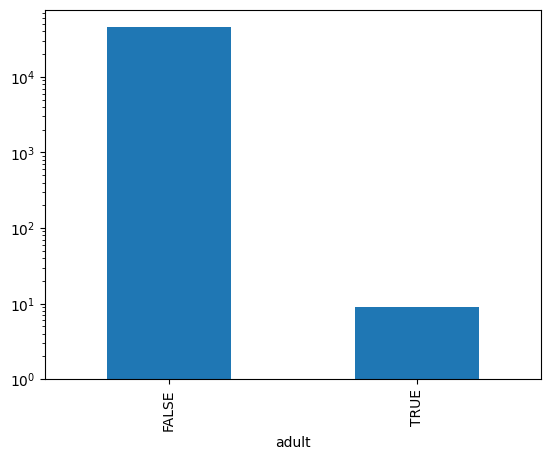

In [107]:
md.adult.value_counts().plot(kind = "bar" , log = True)


In [108]:
md['adult'] = md.adult.map({'FALSE': 0, 'TRUE': 1})


In [109]:
md.sample()


,adult,genres,id,overview,production_companies,production_countries,release_date,runtime,spoken_languages,title,vote_average,vote_count
22430,0,[],83678,"Based on the novel by Maria Gripe, this is the story of two children, Klas and Klara, growing up in the poor Swedish countryside of the mid-19th century. Their father Albert is a glass-blower, famous for his beautiful vases, but still unable to earn enough money for his wife Sofia and the children. At a spring fair a distinguished gentleman arrives and buys all of Albert's glassware. After this nothing will be the same again. Klas and Klara are kidnapped and taken to a strange castle...",[],[],1998,110,[sv],Glasblï¿½ï¿½sarns,6.0,3.0


In [110]:
final_df = md.merge(kd, on='id', how='inner').merge(credits, on='id', how='inner')


In [116]:
final_df.head(1)


,adult,genres,id,overview,production_companies,production_countries,release_date,runtime,spoken_languages,title,vote_average,vote_count,keywords,cast,crew
0,0,"[Animation, Comedy, Family]",862,"Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.",[Pixar Animation Studios],[US],1995,81,[en],Toy Story,7.7,5415.0,"[jealousy, toy, boy, friendship, friends, rivalry, boy next door, new toy, toy comes to life]","[Tom Hanks, Tim Allen, Don Rickles, Jim Varney, Wallace Shawn, John Ratzenberger, Annie Potts, John Morris, Erik von Detten, Laurie Metcalf, R. Lee Ermey, Sarah Freeman, Penn Jillette]","[John Lasseter, Joss Whedon, Andrew Stanton, Joel Cohen, Alec Sokolow, Bonnie Arnold, Ed Catmull, Ralph Guggenheim, Steve Jobs, Lee Unkrich, Ralph Eggleston, Robert Gordon, Mary Helen Leasman, Kim Blanchette, Marilyn McCoppen, Randy Newman, Dale E. Grahn, Robin Cooper, John Lasseter, Pete Docter, Joe Ranft, Patsy Bouge, Norm DeCarlo, Ash Brannon, Randy Newman, Roman Figun, Don Davis, James Flamberg, Mary Beth Smith, Rick Mackay, Susan Bradley, William Reeves, Randy Newman, Andrew Stanton, Pete Docter, Gary Rydstrom, Karen Robert Jackson, Chris Montan, Rich Quade, Michael Berenstein, Colin Brady, Davey Crockett Feiten, Angie Glocka, Rex Grignon, Tom K. Gurney, Jimmy Hayward, Hal T. Hickel, Karen Kiser, Anthony B. LaMolinara, Guionne Leroy, Bud Luckey, Les Major, Glenn McQueen, Mark Oftedal, Jeff Pidgeon, Jeff Pratt, Steve Rabatich, Roger Rose, Steve Segal, Doug Sheppeck, Alan Sperling, Doug Sweetland, David Tart, Ken Willard, Thomas Porter, Mark Thomas Henne, Oren Jacob, Darwyn Peachey, Mitch Prater, Brian M. Rosen, Sharon Calahan, Galyn Susman, William Cone, Shelley Daniels Lekven, Bob Pauley, Bud Luckey, Andrew Stanton, William Cone, Steve Johnson, Dan Haskett, Tom Holloway, Jean Gillmore, Desirée Mourad, Kelly O'Connell, Sonoko Konishi, Ann M. Rockwell, Julie M. McDonald, Robin Lee, Tom Freeman, Ada Cochavi, Dana Mulligan, Deirdre Morrison, Lori Lombardo, Ellen Devine, Lauren Beth Strogoff, Gary Rydstrom, Gary Summers, Tim Holland, Pat Jackson, Tom Myers, ...]"


In [113]:
(md.id == "NA").sum()


np.int64(0)

In [ ]:
def collapse(L):
    L1 = []
    for i in L:
        L1.append(i.replace(" ",""))
    return L1


In [ ]:
final_df['cast'] = final_df['cast'].apply(collapse)
final_df['crew'] = final_df['crew'].apply(collapse)
final_df['genres'] = final_df['genres'].apply(collapse)
final_df['keywords'] = final_df['keywords'].apply(collapse)


In [ ]:
final_df.sample(2)


,adult,genres,id,overview,production_companies,production_countries,release_date,runtime,spoken_languages,title,vote_average,vote_count,keywords,cast,crew
20495,0,"[Horror, Drama, Thriller]",150202,Sequel to the 2009 mezzo-mezzo supernatural horror purporting to be based on a true story in which a cancer-afflicted teen starts seeing things in the new Victorian house he and his family moved into.,[Gold Circle Films],[US],2013,101,[en],The Haunting in Connecticut 2: Ghosts of Georgia,5.6,177.0,"[newhome, ghost, 1990s]","[ChadMichaelMurray, KateeSackhoff, AbigailSpencer, CicelyTyson, EmilyAlynLind, AndreaFrankle, LaurenPennington]","[TomElkins, DavidCoggeshall]"
25815,0,"[Adventure, Action, ScienceFiction]",30305,"Tai gets out of jail and discovers that his twin brother, Tan has been in coma for the past year. Tan has entered the world of Fireball, a violent game based on basketball hosted by underground criminal gangs, to raise money for Tai's early release. However, he was brutally beaten by another player, Tun. Tai agrees to join Den's team so that he can track down the man who hospitalised his brother. Tai is befriended by his teammates: Singh, a Thai boxing champion who wants to prove that he is the best; Muk, a Thai-African guy who needs money to support his family; IQ, a cheerful character who only wants to help his mother; and K, an old friend of Tan who has a mysterious past. He and his teammates must risk their lives and fight their way to the final round of the deadly Fireball championships so that Tai can avenge his brother on the court.","[WVG Medien GmbH, Splendid Film]",[TH],2009,94,[en],Fireball,4.6,11.0,[],"[PreetiBarameeanat, KhanutraChuchuaysuwan, KumpanatOungsoongnern, PhutharitPrombandal, AruchaTosawat, 9MillionSam]","[ThanakornPongsuwan, KiatSansanandana, TaweewatWantha, AdirekWattaleela, ThanakornPongsuwan]"


In [ ]:
final_df['overview'] = final_df['overview'].apply(lambda x:x.split())


In [130]:
from pathlib import Path

processed_dir = Path.cwd().parent / "data" / "processed"

# Make sure the directory exists
processed_dir.mkdir(parents=True, exist_ok=True)

# Build the file path
output_file = processed_dir / "experiment1_output.csv"

# Save DataFrame
final_df.to_csv(output_file, index=False)

print(f" Data exported successfully to {output_file}")


 Data exported successfully to C:\Users\Crashlar\Projects\Movie-Reccommeder-System\data\processed\experiment1_output.csv
